# Single TIFF usage 

In [1]:
import xarray as xr
import xgdal
import os

# Retina resolution for plots
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [2]:
# NOTE: bulk density needs to be x/100 to get units of g cm-3
# But unfortunately the scale factor is not stored in GeoTiff metadata
!gdal raster info /vsicurl/https://storage.googleapis.com/solus100pub/dbovendry_0_cm_p.tif

Driver: GTiff/GeoTIFF
Files: /vsicurl/https://storage.googleapis.com/solus100pub/dbovendry_0_cm_p.tif
Size is 49810, 31390
Coordinate System is:
PROJCRS["unknown",
    BASEGEOGCRS["NAD83",
        DATUM["North American Datum 1983",
            ELLIPSOID["GRS 1980",6378137,298.257222101004,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4269]],
    CONVERSION["Albers Equal Area",
        METHOD["Albers Equal Area",
            ID["EPSG",9822]],
        PARAMETER["Latitude of false origin",23,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8821]],
        PARAMETER["Longitude of false origin",-96,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8822]],
        PARAMETER["Latitude of 1st standard parallel",29.5,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8823]],
        PARAMETER["Latitude of 2nd standard paralle

In [3]:
# Backend expects Cloud URIs (https://, gs://, s3://)
# These are automatically converted to GDAL VSI paths for IO (/vsigs/, /vsis3/) by xgdal
# because in some cases (e.g. dask) xarray understands that gs:// paths are remote and won't try things like os.path.getmtime on them
#url = 'gs://solus100pub/sandtotal_0_cm_p.tif'
#url = 'gs://solus100pub/cec7_0_cm_p.tif'
url = 'https://storage.googleapis.com/solus100pub/dbovendry_0_cm_p.tif'

# Set environment variables with a context manager
# https://gdal.org/en/stable/user/configoptions.html
GDALENV = xgdal.Env(GS_NO_SIGN_REQUEST=True,
                GDAL_DISABLE_READDIR_ON_OPEN='EMPTY_DIR')

with GDALENV:
    da = xr.open_dataarray(url,
        engine='xgdal',
        # # should replace _FillValue in data (255) -> np.NaN (float32)
        mask_and_scale=True,
        backend_kwargs={'overview_level': 2}, # 0 -> first overview leave commented for full res!
    ).squeeze() # remove band dimension of length 1

    da.load()

In [4]:
da = da/100

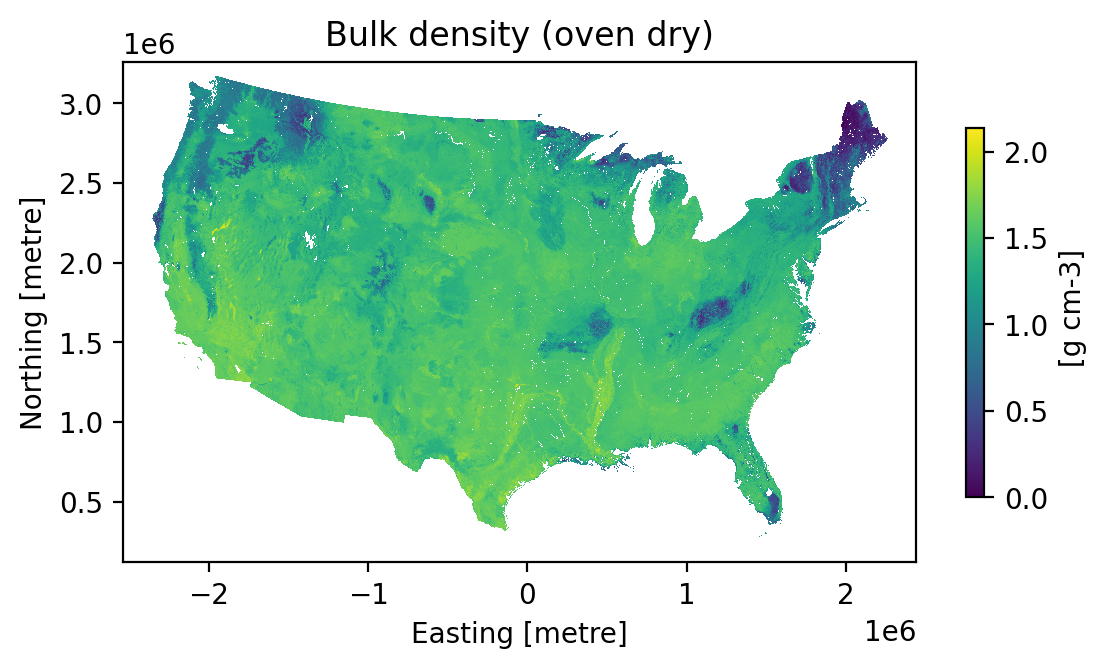

In [5]:
da.attrs['units'] = 'g cm-3' # for colorbar
da.plot.imshow(cbar_kwargs=dict(shrink=0.5))
plt.gca().set_aspect('equal')
plt.title('Bulk density (oven dry)');

In [6]:
da

<xarray.DataArray (y: 3923, x: 6226)> Size: 98MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(3923, 6226), dtype=float32)
Coordinates:
  * y            (y) float64 31kB 3.258e+06 3.257e+06 ... 1.202e+05 1.194e+05
  * x            (x) float64 50kB -2.54e+06 -2.539e+06 ... 2.44e+06 2.441e+06
    band         int64 8B 1
  * spatial_ref  int64 8B 0
Indexes:
    spatial_ref  CRSIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  ┌ x            RasterIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  └ y
Attributes:
    units:    g cm-3

In [7]:
with xr.set_options(display_style="text"):
    print(da)

<xarray.DataArray (y: 3923, x: 6226)> Size: 98MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(3923, 6226), dtype=float32)
Coordinates:
  * y            (y) float64 31kB 3.258e+06 3.257e+06 ... 1.202e+05 1.194e+05
  * x            (x) float64 50kB -2.54e+06 -2.539e+06 ... 2.44e+06 2.441e+06
    band         int64 8B 1
  * spatial_ref  int64 8B 0
Indexes:
    spatial_ref  CRSIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  ┌ x            RasterIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  └ y
Attributes:
    units:    g cm-3


In [8]:
# TODO? We can save a Tiff currently but not a VRT (since GDAL doesn't support writing directly to VRTs)
#da.xgdal.to_raster('/tmp/test.tif')
#da.xgdal.to_raster('test.vrt', driver='VRT') # RuntimeError: Writing through VRTSourcedRasterBand is not supported.

## Selection

Because we're using rasterix, the geotransform is automatically updated after selection.

In [9]:
subset = da.isel(x=slice(0,700), y=slice(200, 400))

In [10]:
subset.xgdal.to_raster('/tmp/test_subset.tif')

In [11]:
da = xr.open_dataarray('/tmp/test_subset.tif', mask_and_scale=True, engine='xgdal').squeeze()


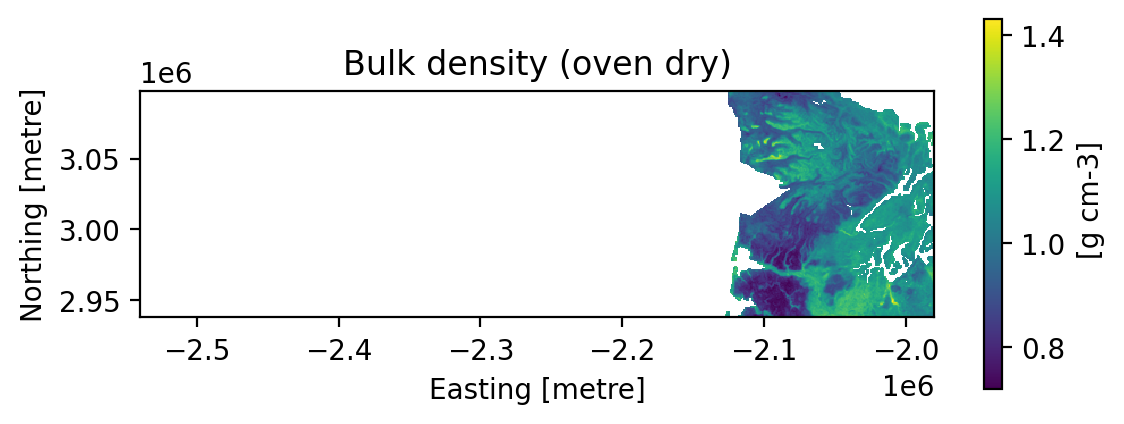

In [12]:
da.attrs['units'] = 'g cm-3' # for colorbar
da.plot.imshow(cbar_kwargs=dict(shrink=0.5))
plt.gca().set_aspect('equal')
plt.title('Bulk density (oven dry)');

In [13]:
# What about Dataset?
with GDALENV:
    ds = xr.open_dataset(url,
                         engine='xgdal',
                         mask_and_scale=False,
                         backend_kwargs={'overview_level': 4})
    ds.load()
ds

<xarray.Dataset> Size: 3MB
Dimensions:                        (band: 1, y: 980, x: 1556)
Coordinates:
  * band                           (band) int64 8B 1
  * y                              (y) float64 8kB 3.256e+06 ... 1.206e+05
  * x                              (x) float64 12kB -2.538e+06 ... 2.439e+06
  * spatial_ref                    int64 8B 0
Data variables:
    __xarray_dataarray_variable__  (band, y, x) uint16 3MB 65535 65535 ... 65535
Indexes:
    spatial_ref  CRSIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  ┌ x            RasterIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  └ y
Attributes:
    geotransform:  (-2540000.0, 3201.1568123393317, 0.0, 3258000.0, 0.0, -320...

In [14]:
os.environ['GS_NO_SIGN_REQUEST'] = 'YES'
os.environ['GDAL_DISABLE_READDIR_ON_OPEN'] = 'EMPTY_DIR'
url = 'https://storage.googleapis.com/solus100pub/cec7_0_cm_p.tif'
da = xr.open_dataarray(url,
                    engine='xgdal',
                    mask_and_scale=False,
                    #chunks={}, # Backend preferred chunks match on-disk chunks
                    #chunks='auto', #~100MB chunks for dask
                    chunks=-1, # single chunk
                    backend_kwargs={'overview_level': 4}
)
da

<xarray.DataArray (band: 1, y: 980, x: 1556)> Size: 3MB
dask.array<open_dataset-__xarray_dataarray_variable__, shape=(1, 980, 1556), dtype=uint16, chunksize=(1, 980, 1556), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 8kB dask.array<chunksize=(980,), meta=np.ndarray>
  * x            (x) float64 12kB dask.array<chunksize=(1556,), meta=np.ndarray>
  * spatial_ref  int64 8B 0
Indexes:
    spatial_ref  CRSIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  ┌ x            RasterIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  └ y
Attributes:
    _FillValue:  65535.0

In [15]:
da.mean().compute()

<xarray.DataArray ()> Size: 8B
array(32959.15433149)
Coordinates:
  * spatial_ref  int64 8B 0
Indexes:
    spatial_ref  CRSIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
Attributes:
    _FillValue:  65535.0